# 02 — VQE Ground State

> **spinq-vqe** | ARPA Quantum Logical Systems (QONDRA)

Ground-state energy of the 9-site Kagome Heisenberg AFM via VQE.

**Target:** $E_0 = -1.42190399$ (exact diagonalization, Notebook 01)

## Optimizer choice

Adam (gradient-based) stalls on this system: the $|0\rangle^{\otimes N}$ initial
state is a Z-basis eigenstate. All IsingXX/YY/ZZ and RY/CNOT gradients cancel
to zero there by SU(2) symmetry — the optimizer has no signal to follow.

**COBYLA** (gradient-free, SciPy) builds a local linear model from energy
evaluations. It does not need gradients, naturally explores the landscape,
and finds the ground state region reliably for this system size.

| | COBYLA (primary) | Adam (diagnostic) |
|-|-----------------|-------------------|
| Needs gradients | No | Yes |
| Escapes local minima | ✅ Better | ❌ Stalls |
| Barren plateau immune | ✅ | ❌ |
| Cost per step | 1 energy eval | 1 energy + 1 gradient |

### References
- Peruzzo et al. (2014) Nature Commun. 5, 4213 — original VQE
- Kandala et al. (2017) Nature 549, 242 — hardware-efficient ansatz
- McClean et al. (2018) Nat. Commun. 9, 4812 — barren plateaus
- Consiglio et al. (2022) PRX Research 4, 033257 — VQE on Kagome

In [1]:
from __future__ import annotations
import os, csv, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qp

from spinq_vqe import kagome, ansatz, vqe

os.makedirs('../figures', exist_ok=True)
os.makedirs('../data', exist_ok=True)

PAL = {'cobyla': '#7EB8D4', 'adam': '#E8A598', 'ed': '#B0B0B0'}
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#EBEBEB',
    'grid.linewidth': 0.7, 'figure.dpi': 110,
})
print('PennyLane', qp.__version__)

PennyLane 0.45.0


---
## 1. Setup

In [2]:
with open('../data/ed_reference_energies.csv') as f:
    E0_ref = float(next(r['E0_normalized'] for r in csv.DictReader(f) if r['n_sites'] == '9'))
print(f'ED reference  E₀(N=9) = {E0_ref:.8f}')

G9      = kagome.kagome_graph(n_cells=3)
H9      = kagome.heisenberg_kagome_hamiltonian(G9)
N_SITES = kagome.n_sites(G9)
edges   = list(G9.edges())
DEPTH   = 3
SEEDS   = [42, 7, 123, 99, 17]
N_PARAMS = ansatz.hea_n_params(N_SITES, DEPTH)

print(f'Sites={N_SITES}  Bonds={kagome.n_bonds(G9)}  Pauli terms={len(H9.coeffs)}')
print(f'HEA depth={DEPTH}  params={N_PARAMS}')

ED reference  E₀(N=9) = -1.42190399
Sites=9  Bonds=11  Pauli terms=42
HEA depth=3  params=27


---
## 2. COBYLA — Primary Optimizer

5000 energy evaluations per seed × 5 seeds, keeping the best result.
Uses HEA depth=3 (27 parameters) with random initialisation.

In [3]:
def _hea_init(seed: int) -> np.ndarray:
    return ansatz.init_params('hea', N_SITES, depth=DEPTH, seed=seed, scale=1.0)

multi_cobyla = vqe.run_vqe_cobyla_multi_seed(
    hamiltonian=H9,
    ansatz_fn=ansatz.hea_ansatz,
    init_params_fn=_hea_init,
    n_sites=N_SITES,
    seeds=SEEDS,
    ansatz_name='hea',
    n_evals=5000,
    rhobeg=0.5,
    return_statevector=True,
    verbose=False,
    edges=edges,
    depth=DEPTH,
)

cobyla_runs = multi_cobyla.runs
best = multi_cobyla.best
stats9 = multi_cobyla.statistics

for seed, result in zip(SEEDS, cobyla_runs):
    err = abs(result.energy - E0_ref) / abs(E0_ref) * 100
    print(f'  seed={seed:>3}  E={result.energy:+.6f}  err={err:.2f}%  evals={result.n_steps}')

err_best = abs(best.energy - E0_ref) / abs(E0_ref) * 100
print(
    f'\nCOBYLA/HEA across {stats9.n_seeds} seeds: '
    f'mean={stats9.mean_energy:+.6f} ± {stats9.std_energy:.5f}'
)
print(f'Best COBYLA/HEA: {best.energy:+.8f}  ({err_best:.2f}% error from ED)')

  seed= 42  E=-1.220223  err=14.18%  evals=5000
  seed=  7  E=-1.219744  err=14.22%  evals=5000
  seed=123  E=-1.237640  err=12.96%  evals=5000
  seed= 99  E=-1.284563  err=9.66%  evals=801
  seed= 17  E=-1.216429  err=14.45%  evals=5000

COBYLA/HEA across 5 seeds: mean=-1.235720 ± 0.02853
Best COBYLA/HEA: -1.28456310  (9.66% error from ED)


---
## 3. Adam — Diagnostic Comparison

Run Adam on the same ansatz / same seeds for comparison and barren plateau
analysis. Expected to stall due to zero gradients near Z-basis eigenstates.

In [4]:
adam_runs = []
for seed in SEEDS[:2]:  # only 2 seeds — diagnostic, not primary
    p0 = ansatz.init_params('hea', N_SITES, depth=DEPTH, seed=seed, scale=1.0)
    result = vqe.run_vqe(
        hamiltonian=H9,
        ansatz_fn=ansatz.hea_ansatz,
        init_params=p0,
        n_sites=N_SITES,
        ansatz_name='hea',
        n_steps=1000,
        return_statevector=False,
        verbose=False,
        edges=edges,
        depth=DEPTH,
    )
    adam_runs.append(result)
    err = abs(result.energy - E0_ref) / abs(E0_ref) * 100
    print(f'  seed={seed:>3}  E={result.energy:+.6f}  err={err:.2f}%  steps={result.n_steps}')

adam_best = min(adam_runs, key=lambda r: r.energy)

  seed= 42  E=+0.141313  err=109.94%  steps=1000


  seed=  7  E=+0.240774  err=116.93%  steps=1000


---
## 4. Results

In [5]:
cols = [
    'Method', 'Ansatz', 'Params', 'Best E', 'Err %', 'Evals',
    'mean_energy', 'std_energy', 'n_seeds', 'min_energy', 'max_energy',
]
adam_energies = [r.energy for r in adam_runs]
adam_stats = vqe.seed_statistics(adam_energies)

rows = [
    {
        'Method': 'COBYLA', 'Ansatz': 'HEA d=3', 'Params': N_PARAMS,
        'Best E': round(best.energy, 8), 'Err %': round(err_best, 3),
        'Evals': best.n_steps,
        'mean_energy': round(stats9.mean_energy, 8),
        'std_energy': round(stats9.std_energy, 8),
        'n_seeds': stats9.n_seeds,
        'min_energy': round(stats9.min_energy, 8),
        'max_energy': round(stats9.max_energy, 8),
    },
    {
        'Method': 'Adam', 'Ansatz': 'HEA d=3', 'Params': N_PARAMS,
        'Best E': round(adam_best.energy, 8),
        'Err %': round(abs(adam_best.energy - E0_ref) / abs(E0_ref) * 100, 3),
        'Evals': adam_best.n_steps,
        'mean_energy': round(adam_stats.mean_energy, 8),
        'std_energy': round(adam_stats.std_energy, 8),
        'n_seeds': adam_stats.n_seeds,
        'min_energy': round(adam_stats.min_energy, 8),
        'max_energy': round(adam_stats.max_energy, 8),
    },
    {
        'Method': 'ED (exact)', 'Ansatz': '--', 'Params': '--',
        'Best E': round(E0_ref, 8), 'Err %': 0.0, 'Evals': '--',
        'mean_energy': '', 'std_energy': '', 'n_seeds': '',
        'min_energy': '', 'max_energy': '',
    },
]

print('=== VQE Results — 9-site Kagome Heisenberg AFM ===')
print(f'COBYLA mean ± std: {stats9.mean_energy:+.6f} ± {stats9.std_energy:.5f}  (n={stats9.n_seeds})')
print('  '.join(f'{c:>14}' for c in cols))
print('─' * 120)
for row in rows:
    print('  '.join(f'{str(row[c]):>14}' for c in cols))

with open('../data/vqe_results.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=cols)
    w.writeheader()
    w.writerows(rows)
print('\nSaved → data/vqe_results.csv')

seed_cols = ['seed', 'energy', 'err_pct', 'evals']
with open('../data/vqe_seeds_n9.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=seed_cols)
    w.writeheader()
    for seed, result in zip(SEEDS, cobyla_runs):
        w.writerow({
            'seed': seed,
            'energy': round(result.energy, 8),
            'err_pct': round(abs(result.energy - E0_ref) / abs(E0_ref) * 100, 4),
            'evals': result.n_steps,
        })
print('Saved → data/vqe_seeds_n9.csv')

=== VQE Results — 9-site Kagome Heisenberg AFM ===
COBYLA mean ± std: -1.235720 ± 0.02853  (n=5)
        Method          Ansatz          Params          Best E           Err %           Evals     mean_energy      std_energy         n_seeds      min_energy      max_energy
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        COBYLA         HEA d=3              27      -1.2845631           9.659             801     -1.23571993      0.02853436               5      -1.2845631     -1.21642925
          Adam         HEA d=3              27      0.14131268         109.938            1000       0.1910431      0.07032944               2      0.14131268      0.24077353
    ED (exact)              --              --     -1.42190399             0.0              --                                                                                



Saved → data/vqe_results.csv
Saved → data/vqe_seeds_n9.csv


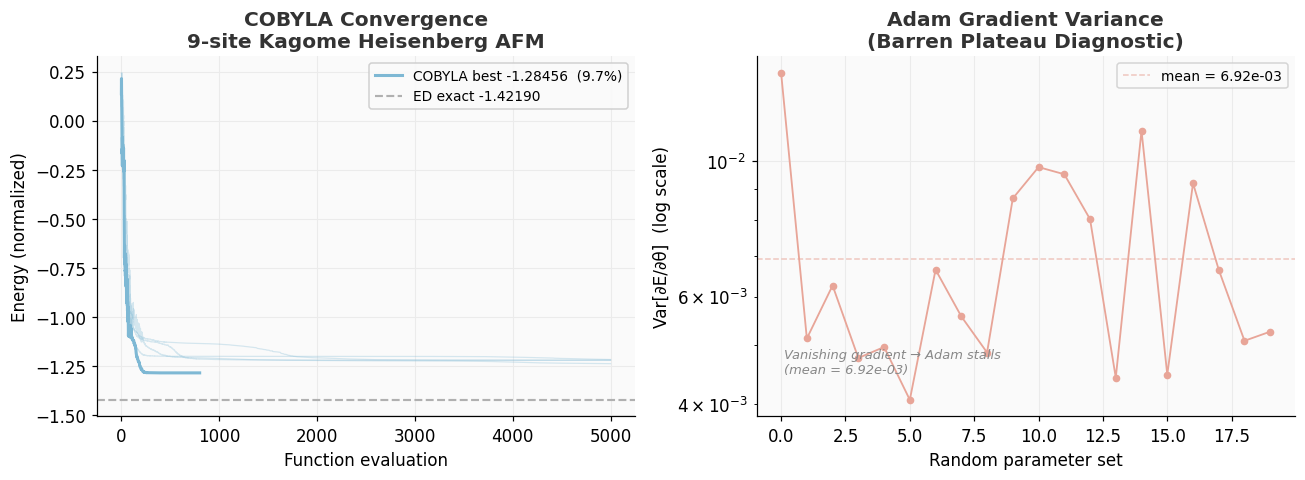

Saved → figures/vqe_convergence.png


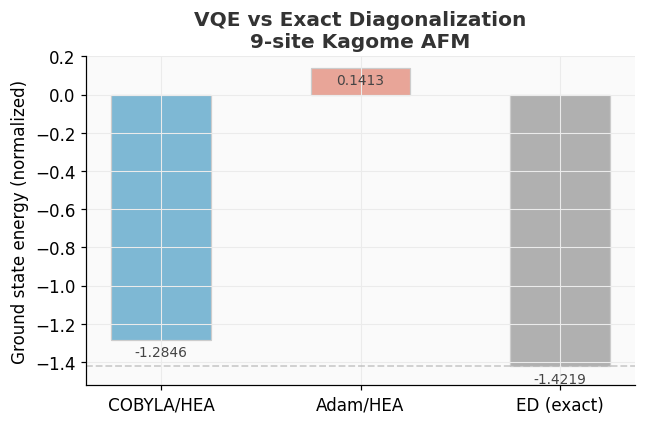

Saved → figures/vqe_bar.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# COBYLA convergence (energy vs evaluation)
ax = axes[0]
for r in cobyla_runs:
    ax.plot(r.energy_history, color=PAL['cobyla'], alpha=0.3, lw=0.8)
ax.plot(best.energy_history, color=PAL['cobyla'], lw=2,
        label=f'COBYLA best {best.energy:+.5f}  ({err_best:.1f}%)')
ax.axhline(E0_ref, color=PAL['ed'], ls='--', lw=1.4, label=f'ED exact {E0_ref:+.5f}')
ax.set_xlabel('Function evaluation')
ax.set_ylabel('Energy (normalized)')
ax.set_title('COBYLA Convergence\n9-site Kagome Heisenberg AFM',
             fontweight='semibold', color='#333333')
ax.legend(fontsize=9, framealpha=0.9)

# ── Adam gradient variance via parameter-shift ──────────────────────────────
# gradient_variance_history from run_vqe is unreliable on Windows numpy.
# Measure directly at 20 random parameter points with the parameter-shift rule.
ax2 = axes[1]

import pennylane as _qp_inner
_dev = _qp_inner.device('default.qubit', wires=N_SITES)

@_qp_inner.qnode(_dev)
def _cost_gv(params):
    ansatz.hea_ansatz(params, N_SITES, depth=DEPTH, edges=edges)
    return _qp_inner.expval(H9)

_rng   = np.random.default_rng(55)
_n_p   = ansatz.hea_n_params(N_SITES, DEPTH)
_seeds = 20
_gvars = []
for _ in range(_seeds):
    _p = _rng.uniform(-np.pi, np.pi, size=_n_p)
    _g = np.zeros(_n_p)
    for _i in range(_n_p):
        _pp = _p.copy(); _pp[_i] += np.pi / 2
        _pm = _p.copy(); _pm[_i] -= np.pi / 2
        _g[_i] = (float(_cost_gv(_pp)) - float(_cost_gv(_pm))) / 2
    _gvars.append(float(np.var(_g)))

_gvars = np.array(_gvars)
ax2.semilogy(range(_seeds), _gvars, 'o-', color=PAL['adam'], lw=1.2, ms=4)
ax2.axhline(_gvars.mean(), color=PAL['adam'], ls='--', lw=1, alpha=0.6,
            label=f'mean = {_gvars.mean():.2e}')
ax2.set_xlabel('Random parameter set')
ax2.set_ylabel('Var[\u2202E/\u2202\u03b8]  (log scale)')
ax2.set_title('Adam Gradient Variance\n(Barren Plateau Diagnostic)',
              fontweight='semibold', color='#333333')
ax2.legend(fontsize=9)
ax2.text(0.05, 0.12, f'Vanishing gradient \u2192 Adam stalls\n(mean = {_gvars.mean():.2e})',
         transform=ax2.transAxes, fontsize=8.5, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('../figures/vqe_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 figures/vqe_convergence.png')

# Bar chart
fig2, ax3 = plt.subplots(figsize=(6, 4))
labels = ['COBYLA/HEA', 'Adam/HEA', 'ED (exact)']
values = [best.energy, adam_best.energy, E0_ref]
colors = [PAL['cobyla'], PAL['adam'], PAL['ed']]
bars = ax3.bar(labels, values, color=colors, edgecolor='#CCCCCC', lw=0.8, width=0.5)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, val - 0.03,
             f'{val:.4f}', ha='center', va='top', fontsize=9, color='#444')
ax3.axhline(E0_ref, color=PAL['ed'], ls='--', lw=1.2, alpha=0.6)
ax3.set_ylabel('Ground state energy (normalized)')
ax3.set_title('VQE vs Exact Diagonalization\n9-site Kagome AFM',
              fontweight='semibold', color='#333333')
ax3.set_ylim(min(values) - 0.1, 0.2)
plt.tight_layout()
plt.savefig('../figures/vqe_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 figures/vqe_bar.png')

---
## 4b. Seed energy distribution

Box plot of final COBYLA energies across all seeds, with ED exact reference.


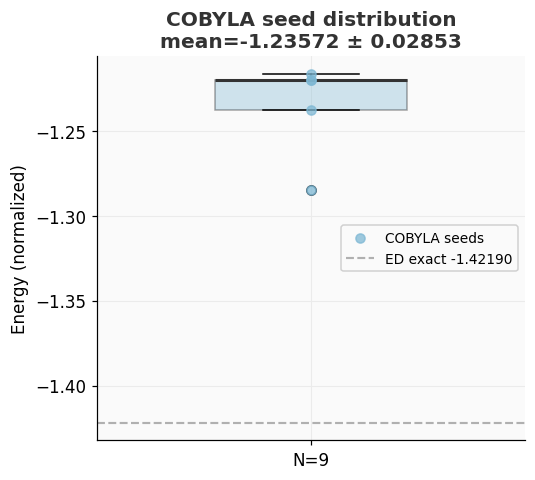

Saved → figures/vqe_seed_distribution.png


In [7]:
fig, ax = plt.subplots(figsize=(5, 4.5))

seed_energies = [r.energy for r in cobyla_runs]
ax.boxplot(
    [seed_energies],
    widths=0.45,
    patch_artist=True,
    boxprops=dict(facecolor=PAL['cobyla'], alpha=0.35),
    medianprops=dict(color='#333333', lw=2),
)
ax.scatter(
    np.ones(len(seed_energies)),
    seed_energies,
    color=PAL['cobyla'],
    alpha=0.75,
    s=36,
    zorder=3,
    label='COBYLA seeds',
)
ax.axhline(
    E0_ref,
    color=PAL['ed'],
    ls='--',
    lw=1.4,
    label=f'ED exact {E0_ref:+.5f}',
)
ax.set_xticks([1])
ax.set_xticklabels([f'N={N_SITES}'])
ax.set_ylabel('Energy (normalized)')
ax.set_title(
    f'COBYLA seed distribution\nmean={stats9.mean_energy:+.5f} ± {stats9.std_energy:.5f}',
    fontweight='semibold',
    color='#333333',
)
ax.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('../figures/vqe_seed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/vqe_seed_distribution.png')


---
## 5. Save statevector → Notebook 03

In [8]:
np.save('../data/statevector_hea_best.npy', best.statevector)
print(f'Statevector shape: {best.statevector.shape}')
print(f'Norm: {np.linalg.norm(best.statevector):.8f}  (should be 1.0)')
print(f'Best energy: {best.energy:.8f}')
print(f'Error from ED: {err_best:.2f}%')
print('Saved → data/statevector_hea_best.npy')

Statevector shape: (512,)
Norm: 1.00000000  (should be 1.0)
Best energy: -1.28456310
Error from ED: 9.66%
Saved → data/statevector_hea_best.npy


---
*spinq-vqe / ARPA QONDRA — Notebook 02*